# 01. Análise exploratória dos dados

Este notebook executa a exploração dos dados do **AprovaEdu Analytics**, analisando a distribuição dos estudantes, matrículas, notas de simulados e histórico de aprovações.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RAW_DIR = Path("../data/raw")
sns.set_theme(style="whitegrid")

## 1. Perfil dos Estudantes

In [2]:
estudantes = pd.read_csv(RAW_DIR / "estudantes.csv", encoding="utf-8-sig")
display(estudantes.head())
display(estudantes.info())

,aluno_id,nome_aluno,cpf_ficticio,email_aluno,telefone,data_nascimento,cidade,escola_origem,data_cadastro,canal_captacao
0,A00001,Carla Barbosa Silva,625.588.977-17,carla.silva304@aluno.ficticio.com,(85) 97055-6219,2005-11-08,fortaleza,Não informado,2023-01-15,Instagram
1,A00002,Miguel Silva Ribeiro,89233633131,miguel.ribeiro639@aluno.ficticio.com,(85) 93920-1613,2005-11-08,Crato,Federal,2025-03-11,Feira escolar
2,A00003,Gabriela Rodrigues Moura,NaN,gabriela.moura824@aluno.ficticio.com,(85) 99873-6068,2003-01-23,Horizonte,Privada,2022-01-15,Indicação
3,A00004,Gustavo Correia Martins,832.173.860-56,gustavo.martins730@aluno.ficticio.com,(85) 91408-2238,2004-06-19,Juazeiro do Norte,Publica,03-16-2021,Google
4,A00005,Eduarda Rocha Gomes,958.199.764-51,eduarda.gomes400@aluno.ficticio.com,(85) 96283-2856,2008-07-03,Caucaia,NaN,2022-02-21,WhatsApp


<class 'pandas.DataFrame'>
RangeIndex: 812 entries, 0 to 811
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   aluno_id         812 non-null    str  
 1   nome_aluno       812 non-null    str  
 2   cpf_ficticio     790 non-null    str  
 3   email_aluno      764 non-null    str  
 4   telefone         732 non-null    str  
 5   data_nascimento  812 non-null    str  
 6   cidade           812 non-null    str  
 7   escola_origem    723 non-null    str  
 8   data_cadastro    812 non-null    str  
 9   canal_captacao   681 non-null    str  
dtypes: str(10)
memory usage: 167.3 KB


None

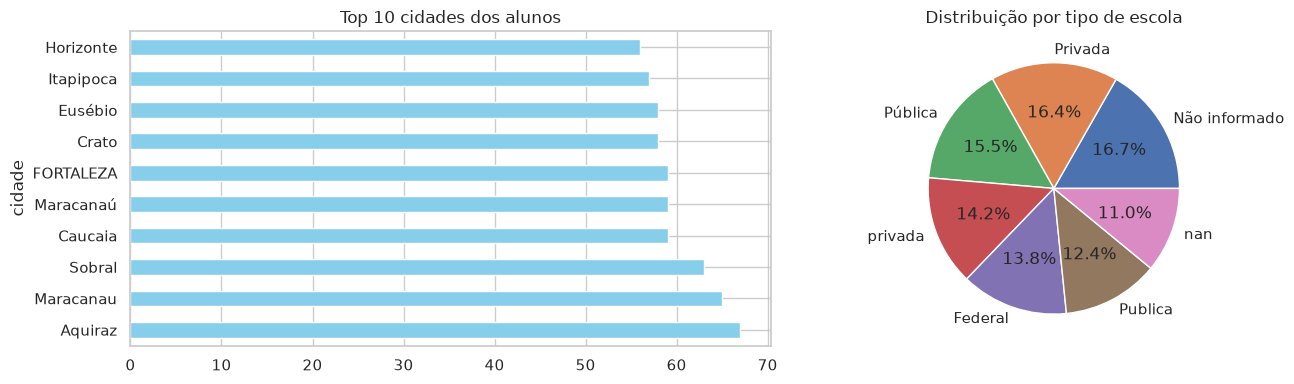

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

estudantes['cidade'].value_counts().head(10).plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title("Top 10 cidades dos alunos")

estudantes['escola_origem'].value_counts(dropna=False).plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title("Distribuição por tipo de escola")

plt.tight_layout()
plt.show()

## 2. Matrículas e Disciplinas

,matricula_id,aluno_id,oferta_id,ano,materia_declarada,data_matricula,bolsa_percentual,status_matricula,nota_diagnostico,origem_captacao
0,M0000001,A00001,O20230092,2023,Biologia,2023-03-06,25.0,Concluída,58.3,Feira escolar
1,M0000002,A00001,O20230090,2023,Física,2023-01-20,20.0,Concluída,54.2,Google
2,M0000003,A00001,O20230094,2023,Geografia,2023-04-22,50.0,Concluída,53.1,WhatsApp
3,M0000004,A00001,O20230097,2023,Inglês,2023-03-06,0.0,Concluída,70.4,Google
4,M0000005,A00001,O20230089,2023,Matemática,2023-04-06,10.0,Concluída,51.3,Indicação


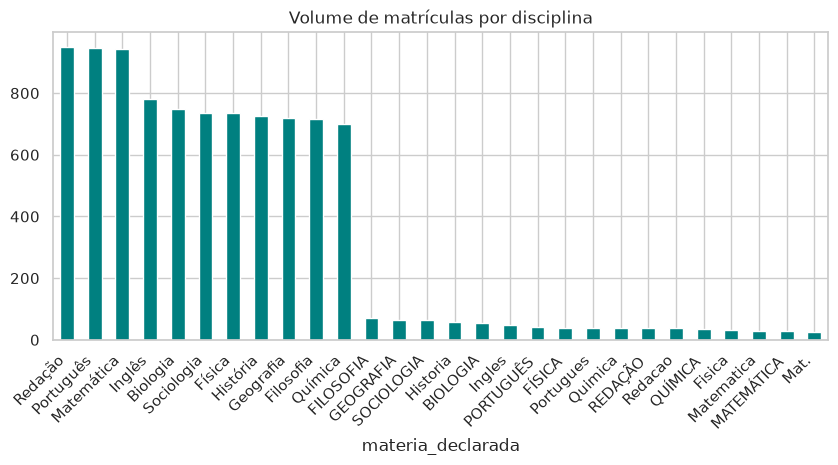

In [4]:
matriculas = pd.read_csv(RAW_DIR / "matriculas.csv", encoding="utf-8-sig")
display(matriculas.head())

plt.figure(figsize=(10, 4))
matriculas['materia_declarada'].value_counts().plot(kind='bar', color='teal')
plt.title("Volume de matrículas por disciplina")
plt.xticks(rotation=45, ha='right')
plt.show()

## 3. Desempenho nos Simulados

,resultado_id,simulado_id,aluno_id,ano,status_realizacao,nota,acertos,tempo_finalizacao_min,inicio_simulado,dispositivo,tentativas,unidade_aplicacao
0,R00000001,S20210001,A00775,2021,Finalizado,92.6,55.0,319.0,28/05/2021 12:00,desktop,1.0,Online
1,R00000002,S20210001,A00530,2021,Finalizado,78.9,49.0,200.0,2021-10-10 10:00,Papel,NaN,online
2,R00000003,S20210001,A00227,2021,Ausente,NaN,NaN,NaN,2021-04-13 13:30,Papel,3.0,online
3,R00000004,S20210001,A00521,2021,Ausente,NaN,NaN,NaN,2021-06-20 13:15,Celular,1.0,Centro
4,R00000005,S20210001,A00078,2021,Finalizado,84.3,52.0,162.0,2021-10-08 11:00,desktop,1.0,Aldeota


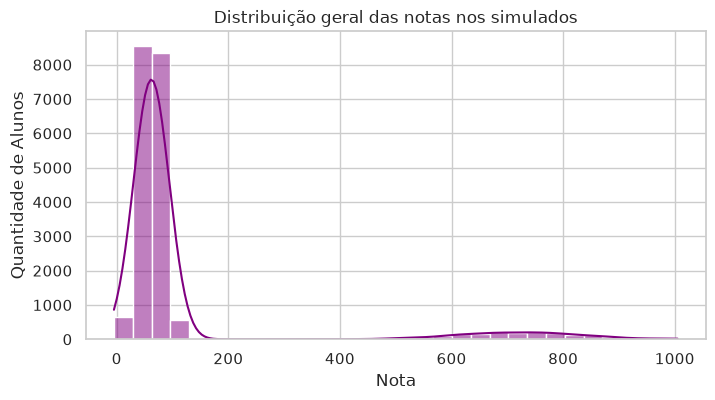

In [5]:
resultados = pd.read_csv(RAW_DIR / "resultados_simulados.csv", encoding="utf-8-sig")
display(resultados.head())

plt.figure(figsize=(8, 4))
sns.histplot(resultados['nota'].dropna(), kde=True, color='purple', bins=30)
plt.title("Distribuição geral das notas nos simulados")
plt.xlabel("Nota")
plt.ylabel("Quantidade de Alunos")
plt.show()

## 4. Histórico de Aprovações no Vestibular

,aprovacao_id,ano_vestibular,aluno_id,universidade,curso_aprovado,modalidade_vaga,chamada,bolsa_aprovacao,data_resultado,nota_final_vestibular,campus
0,V000001,2021,A00024,uece,Arquitetura,PPI,SISU,Sim,2021-12-27,745.6,Crateús
1,V000002,2021,A00025,UNILAB,Engenharia Civil,Cota escola pública,Vestibular próprio,Não,2021-01-08,674.4,Quixadá
2,V000003,2021,A00026,UFRN,Enfermagem,PCD,SISU,Sim,2021-03-19,686.5,Fortaleza
3,V000004,2021,A00046,UFC,Jornalismo,PCD,2ª chamada,Parcial,2021-03-08,837.4,Fortaleza
4,V000005,2021,A00085,UFCA,Enfermagem,PCD,Vestibular próprio,NaN,2021-12-21,673.6,Juazeiro


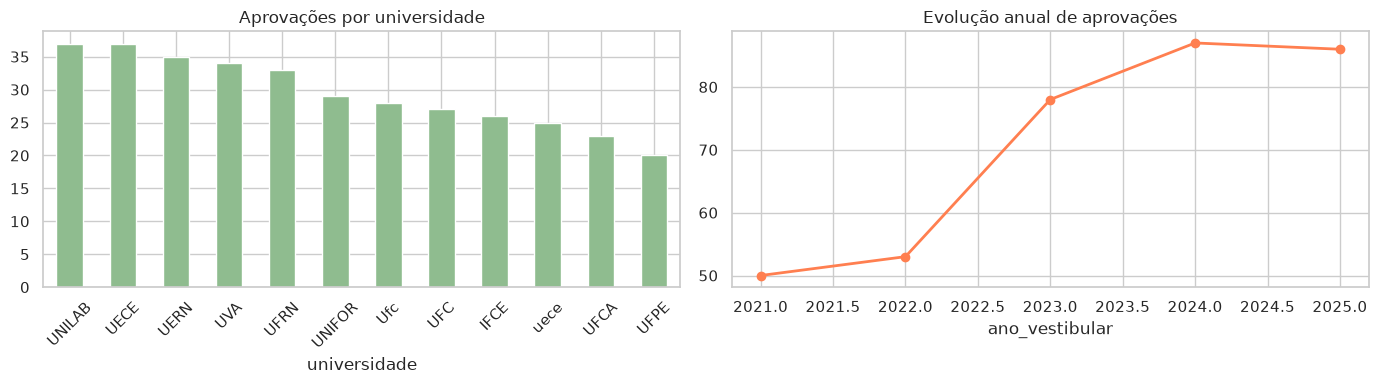

In [6]:
aprovacoes = pd.read_csv(RAW_DIR / "aprovacoes_vestibular.csv", encoding="utf-8-sig")
display(aprovacoes.head())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
aprovacoes['universidade'].value_counts().plot(kind='bar', ax=axes[0], color='darkseagreen')
axes[0].set_title("Aprovações por universidade")
axes[0].tick_params(axis='x', rotation=45)

aprovacoes['ano_vestibular'].value_counts().sort_index().plot(kind='line', marker='o', ax=axes[1], color='coral', linewidth=2)
axes[1].set_title("Evolução anual de aprovações")

plt.tight_layout()
plt.show()